### Exploratory Data Analysis: Electricity Demand Zurich (2022-2025)

Goal:
Visualize the dataset to uncover underlying patterns in Swiss electricity demand, analyzing how it shifts across hours, days, seasons, and varying weather conditions.

Why did we use it?
To visually prove the complexity of the grid before modeling, which tells us exactly what features and model architectures we will need later.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})

df = pd.read_csv('../data/processed/hourly_merged.csv', index_col='datetime_utc')
df.index = pd.to_datetime(df.index, utc=True)
df['year'] = df.index.year

print(f'Shape: {df.shape}')
df.head(3)

Shape: (35045, 20)


,demand,T,Hr,StrGlo,RainDur,WVv,p,hour,dayofweek,month,is_weekend,season,hour_sin,hour_cos,month_sin,month_cos,demand_log,is_peak,peak_hours_per_day,year
datetime_utc,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00+00:00,60787.89700,6.78,83.34,0.02,0.0,0.90,977.07,1,5,1,1,winter,0.258819,0.965926,0.5,0.866025,11.015146,0,0,2022
2022-01-01 01:00:00+00:00,59943.68675,6.42,84.66,0.03,0.0,0.70,977.14,2,5,1,1,winter,0.500000,0.866025,0.5,0.866025,11.001161,0,0,2022
2022-01-01 02:00:00+00:00,57751.22200,6.15,84.61,0.02,0.0,0.49,977.38,3,5,1,1,winter,0.707107,0.707107,0.5,0.866025,10.963900,0,0,2022


#### 1. Demand Distribution

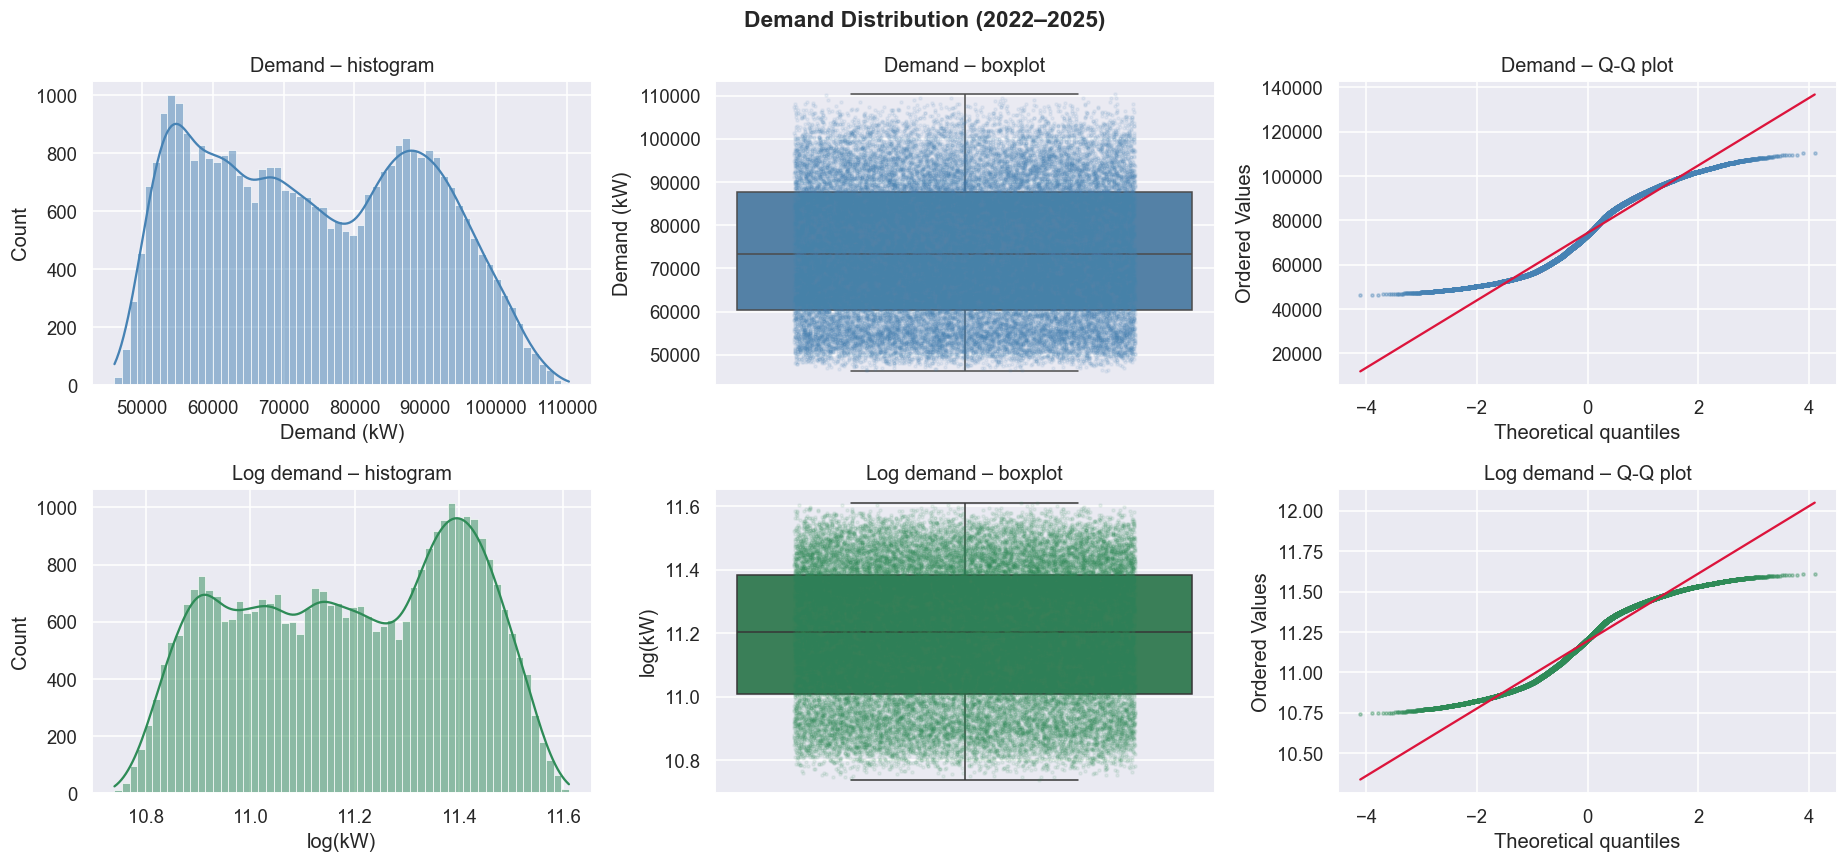

In [2]:
from scipy import stats
import os

os.makedirs('../outputs/figures/01_eda', exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(17, 8))

# Row 0: raw demand
sns.histplot(df['demand'], bins=60, ax=axes[0, 0], kde=True, color='steelblue')
axes[0, 0].set_title('Demand – histogram')
axes[0, 0].set_xlabel('Demand (kW)')

sns.boxplot(y=df['demand'], ax=axes[0, 1], color='steelblue', width=0.4)
axes[0, 1].set_title('Demand – boxplot')
axes[0, 1].set_ylabel('Demand (kW)')
axes[0, 1].scatter(
    np.random.uniform(-0.15, 0.15, size=len(df['demand'].dropna())),
    df['demand'].dropna().values,
    alpha=0.08, s=4, color='steelblue', zorder=3
)

stats.probplot(df['demand'].dropna(), dist='norm', plot=axes[0, 2])
axes[0, 2].set_title('Demand – Q-Q plot')
axes[0, 2].get_lines()[0].set(markersize=2, alpha=0.35, color='steelblue')
axes[0, 2].get_lines()[1].set(color='crimson')

# Row 1: log demand
sns.histplot(df['demand_log'], bins=60, ax=axes[1, 0], kde=True, color='seagreen')
axes[1, 0].set_title('Log demand – histogram')
axes[1, 0].set_xlabel('log(kW)')

sns.boxplot(y=df['demand_log'], ax=axes[1, 1], color='seagreen', width=0.4)
axes[1, 1].set_title('Log demand – boxplot')
axes[1, 1].set_ylabel('log(kW)')
axes[1, 1].scatter(
    np.random.uniform(-0.15, 0.15, size=len(df['demand_log'].dropna())),
    df['demand_log'].dropna().values,
    alpha=0.08, s=4, color='seagreen', zorder=3
)

stats.probplot(df['demand_log'].dropna(), dist='norm', plot=axes[1, 2])
axes[1, 2].set_title('Log demand – Q-Q plot')
axes[1, 2].get_lines()[0].set(markersize=2, alpha=0.35, color='seagreen')
axes[1, 2].get_lines()[1].set(color='crimson')

fig.suptitle('Demand Distribution (2022–2025)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/01_eda/01_demand_distribution.png', bbox_inches='tight')
plt.show()

#### 2. Time Series by Year

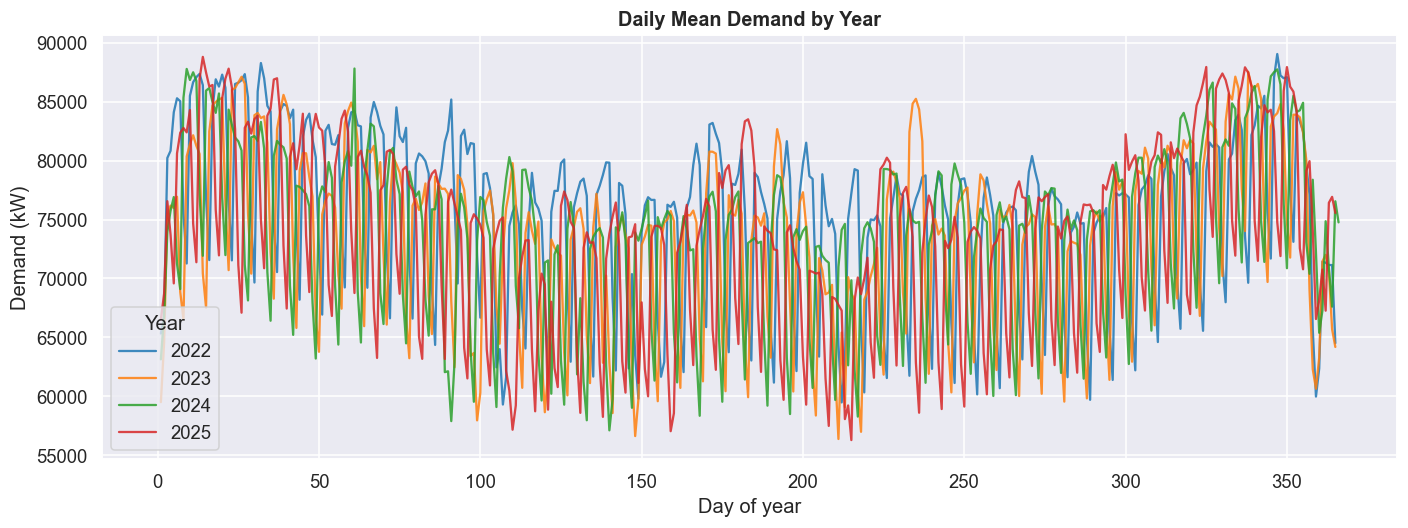

In [3]:
daily = df['demand'].resample('D').mean().rename('demand').reset_index()
daily['year'] = daily['datetime_utc'].dt.year
daily['doy']  = daily['datetime_utc'].dt.dayofyear

fig, ax = plt.subplots(figsize=(13, 5))
for year, grp in daily.groupby('year'):
    ax.plot(grp['doy'], grp['demand'], lw=1.5, label=str(year), alpha=0.85)

ax.set_xlabel('Day of year')
ax.set_ylabel('Demand (kW)')
ax.set_title('Daily Mean Demand by Year', fontweight='bold')
ax.legend(title='Year')
plt.tight_layout()
plt.savefig('../outputs/figures/01_eda/01_02_timeseries_by_year.png', bbox_inches='tight')
plt.show()

#### 3. Temporal Patterns

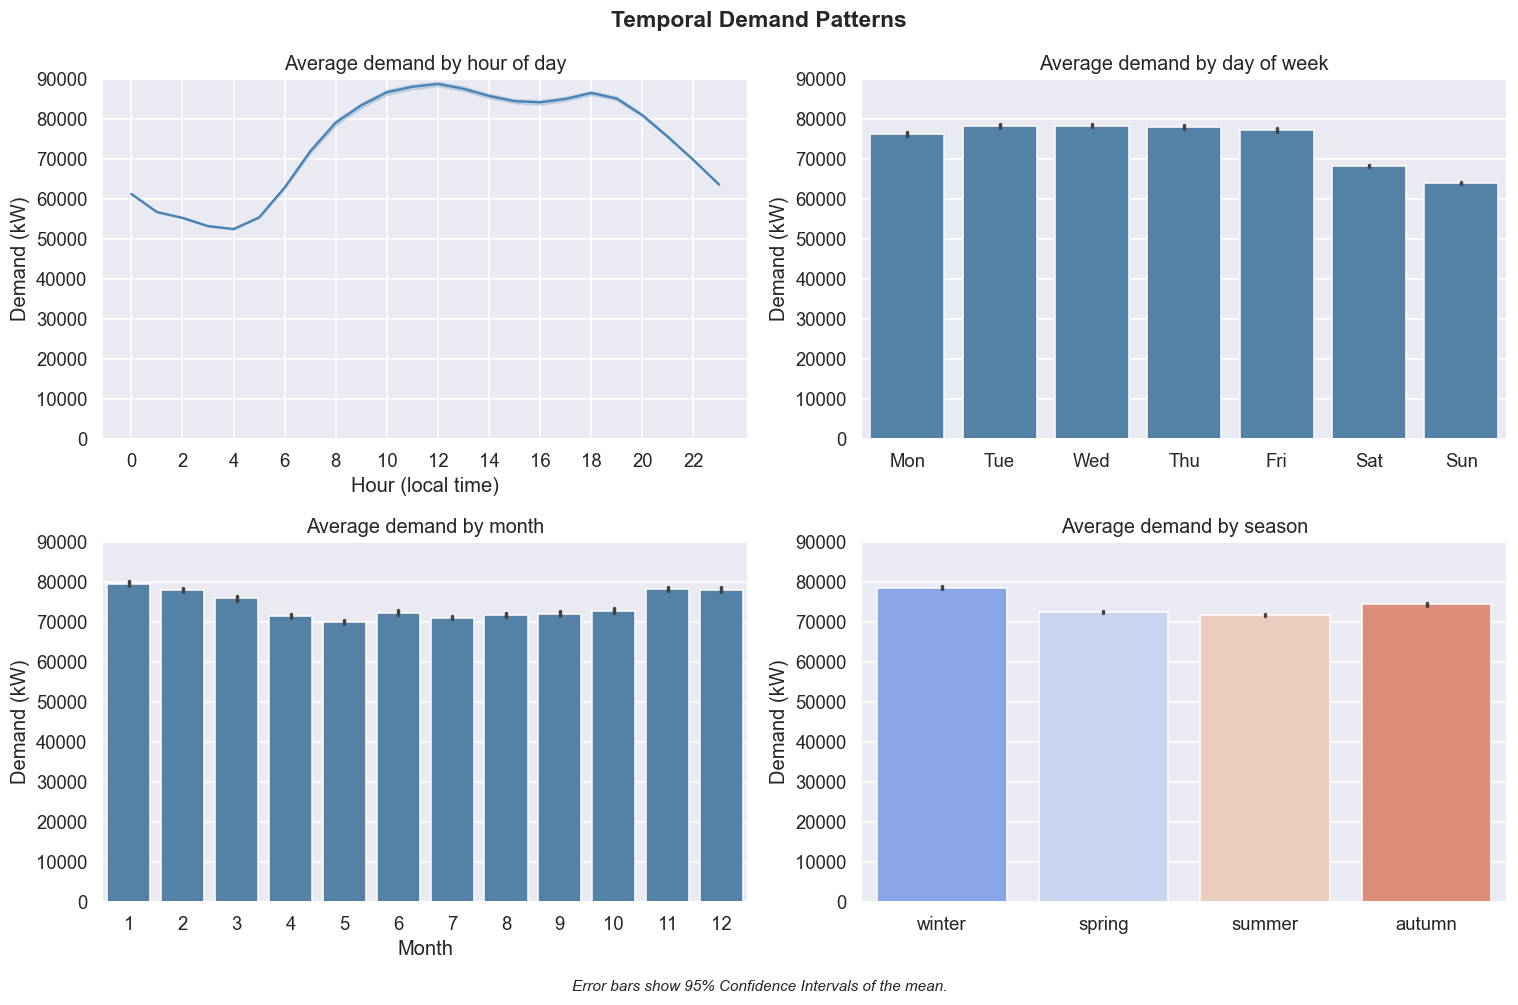

In [4]:
season_order = ['winter', 'spring', 'summer', 'autumn']
day_labels   = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
Y_MIN, Y_MAX = 0, 90_000

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# by hour
sns.lineplot(data=df, x='hour', y='demand', ax=axes[0, 0],
             errorbar='ci', color='steelblue')
axes[0, 0].set_title('Average demand by hour of day')
axes[0, 0].set_xlabel('Hour (local time)')
axes[0, 0].set_ylabel('Demand (kW)')
axes[0, 0].set_xticks(range(0, 24, 2))
axes[0, 0].set_ylim(Y_MIN, Y_MAX)

# by day of week
sns.barplot(data=df, x='dayofweek', y='demand', ax=axes[0, 1],
            errorbar='ci', color='steelblue')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(day_labels)
axes[0, 1].set_title('Average demand by day of week')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Demand (kW)')
axes[0, 1].set_ylim(Y_MIN, Y_MAX)

# by month
sns.barplot(data=df, x='month', y='demand', ax=axes[1, 0],
            errorbar='ci', color='steelblue')
axes[1, 0].set_title('Average demand by month')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Demand (kW)')
axes[1, 0].set_ylim(Y_MIN, Y_MAX)

# by season
sns.barplot(data=df, x='season', y='demand', order=season_order,
            hue='season', legend=False,
            ax=axes[1, 1], errorbar='ci', palette='coolwarm')
axes[1, 1].set_title('Average demand by season')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('Demand (kW)')
axes[1, 1].set_ylim(Y_MIN, Y_MAX)

fig.suptitle('Temporal Demand Patterns', fontsize=15, fontweight='bold')
fig.text(0.5, -0.01, 'Error bars show 95% Confidence Intervals of the mean.',
         ha='center', fontsize=10, style='italic')
plt.tight_layout()
plt.savefig('../outputs/figures/01_eda/01_03_temporal_patterns.png', bbox_inches='tight')
plt.show()

#### 4. Demand vs Weather

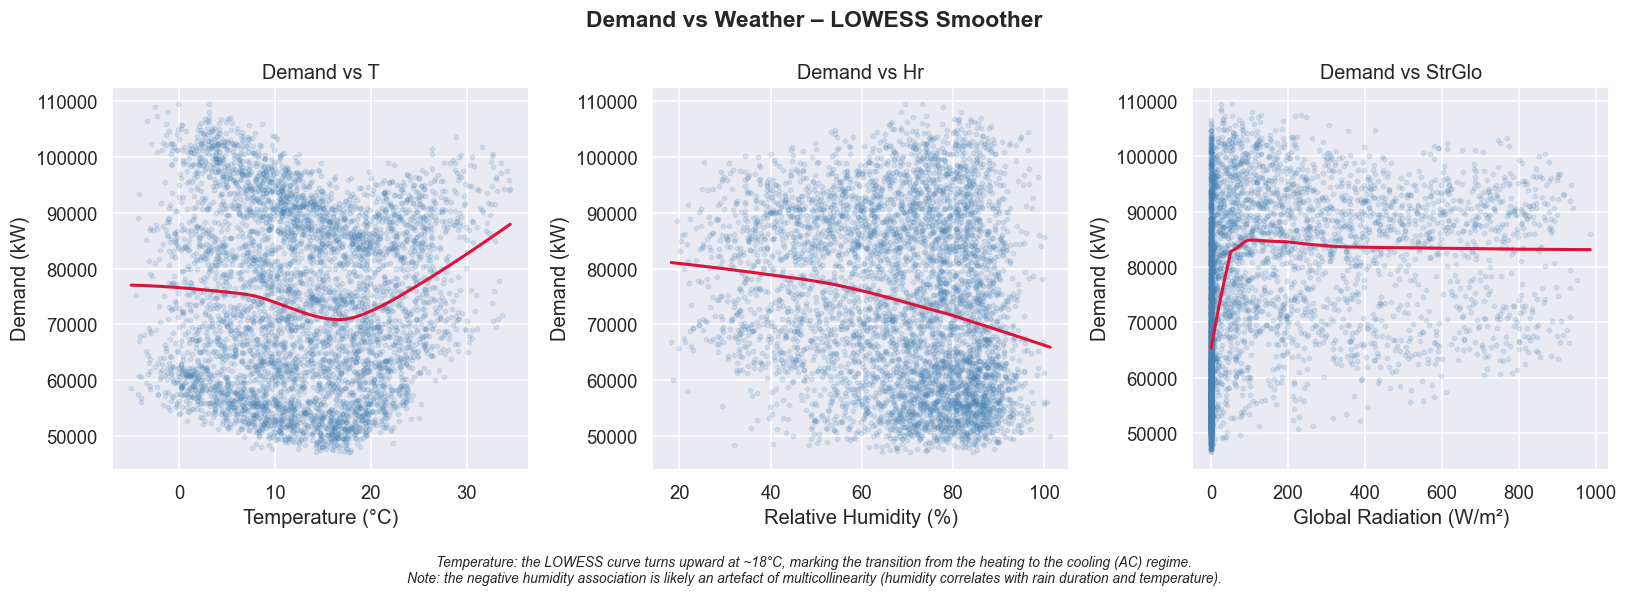

In [5]:
weather_vars = {
    'T':      'Temperature (°C)',
    'Hr':     'Relative Humidity (%)',
    'StrGlo': 'Global Radiation (W/m²)',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, label) in zip(axes, weather_vars.items()):
    sample = df[['demand', col]].dropna().sample(5000, random_state=42)
    sns.regplot(data=sample, x=col, y='demand', ax=ax,
                scatter_kws={'alpha': 0.15, 's': 8, 'color': 'steelblue'},
                lowess=True,
                line_kws={'color': 'crimson', 'lw': 2})
    ax.set_xlabel(label)
    ax.set_ylabel('Demand (kW)')
    ax.set_title(f'Demand vs {col}')

fig.suptitle('Demand vs Weather – LOWESS Smoother', fontsize=15, fontweight='bold')
fig.text(
    0.5, -0.06,
    'Temperature: the LOWESS curve turns upward at ~18°C, marking the transition from the heating to the cooling (AC) regime.\n'
    'Note: the negative humidity association is likely an artefact of multicollinearity (humidity correlates with rain duration and temperature).',
    ha='center', fontsize=9, style='italic'
)
plt.tight_layout()
plt.savefig('../outputs/figures/01_eda/01_04_demand_vs_weather.png', bbox_inches='tight')
plt.show()

#### 5. Correlation Heatmap

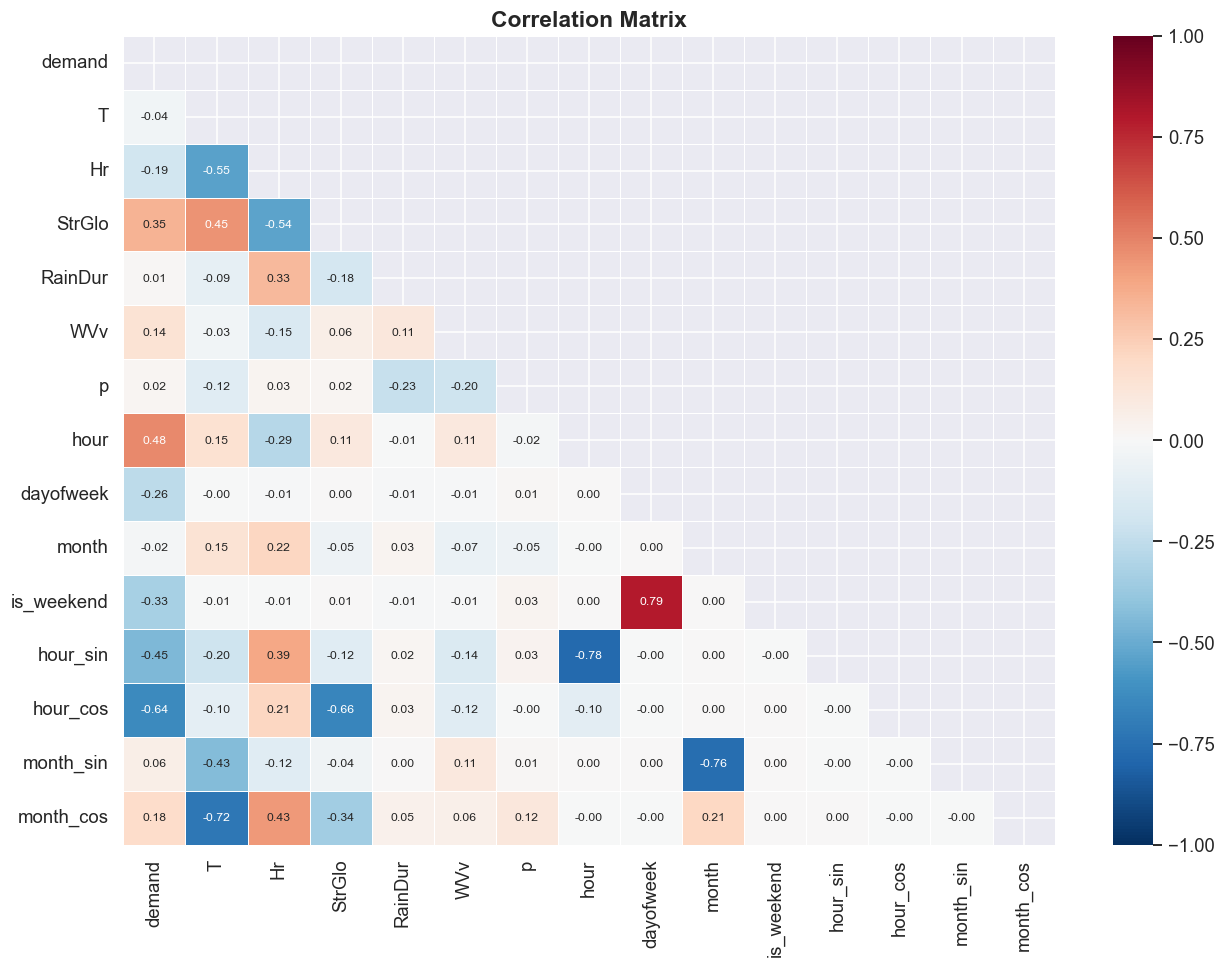

In [6]:
corr_cols = ['demand', 'T', 'Hr', 'StrGlo', 'RainDur', 'WVv', 'p',
             'hour', 'dayofweek', 'month', 'is_weekend',
             'hour_sin', 'hour_cos', 'month_sin', 'month_cos']

corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/01_eda/01_05_correlation_heatmap.png', bbox_inches='tight')
plt.show()

#### 6. Target Variables

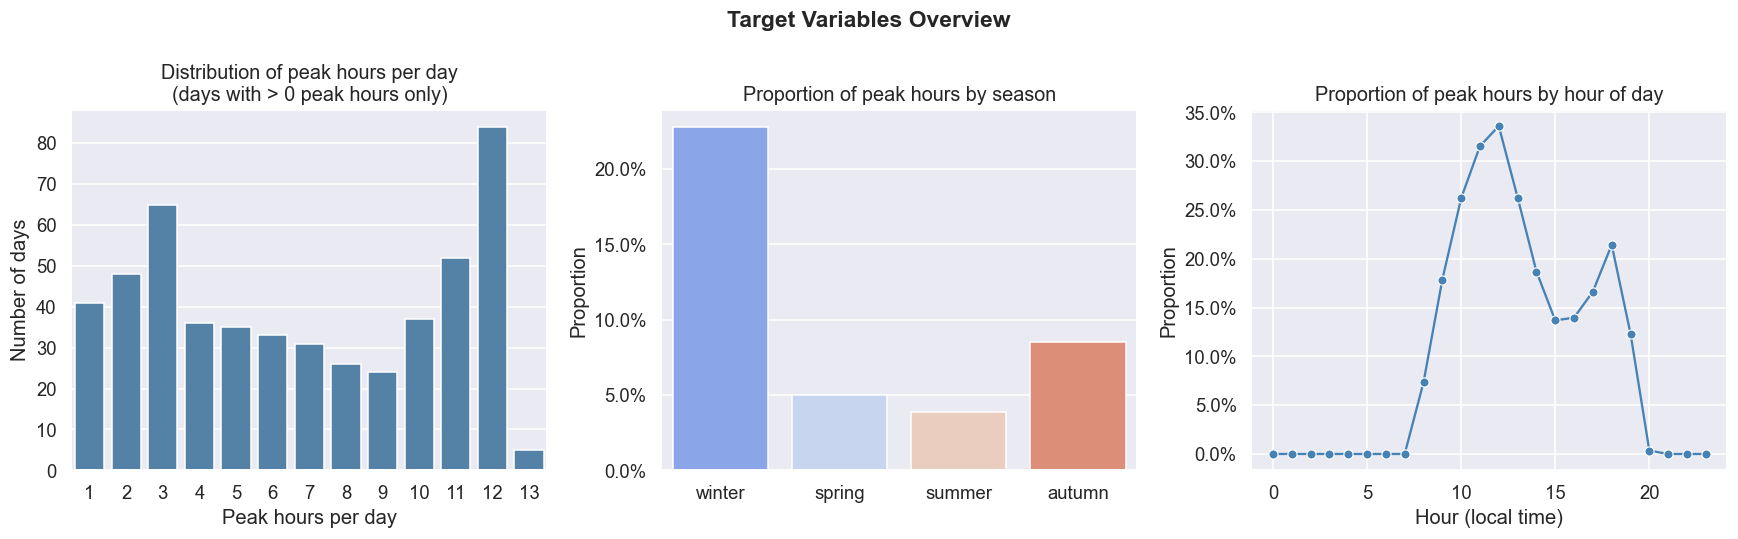

In [7]:
# one value per day for peak_hours_per_day
daily_peaks = df['peak_hours_per_day'].resample('D').first()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: filter out zero-peak days
nonzero_peaks = daily_peaks[daily_peaks > 0]
vc = nonzero_peaks.value_counts().sort_index().reset_index()
vc.columns = ['peak_hours', 'count']
sns.barplot(data=vc, x='peak_hours', y='count', ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of peak hours per day\n(days with > 0 peak hours only)')
axes[0].set_xlabel('Peak hours per day')
axes[0].set_ylabel('Number of days')

# Panel 2: proportion by season (unchanged)
peak_by_season = (df.groupby('season')['is_peak']
                  .mean()
                  .reindex(['winter', 'spring', 'summer', 'autumn'])
                  .reset_index())
peak_by_season.columns = ['season', 'prop_peak']
sns.barplot(data=peak_by_season, x='season', y='prop_peak',
            ax=axes[1], palette='coolwarm', hue='season', legend=False)
axes[1].set_title('Proportion of peak hours by season')
axes[1].set_xlabel('')
axes[1].set_ylabel('Proportion')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Panel 3: line plot instead of bar plot
peak_by_hour = df.groupby('hour')['is_peak'].mean().reset_index()
peak_by_hour.columns = ['hour', 'prop_peak']
sns.lineplot(data=peak_by_hour, x='hour', y='prop_peak',
             ax=axes[2], marker='o', color='steelblue')
axes[2].set_title('Proportion of peak hours by hour of day')
axes[2].set_xlabel('Hour (local time)')
axes[2].set_ylabel('Proportion')
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

fig.suptitle('Target Variables Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/01_eda/01_06_targets.png', bbox_inches='tight')
plt.show()

#### 7. NE5 vs NE7

NE5 and NE7 were merged into demand during preprocessing, so this is skipped.

In [8]:
# NE5 and NE7 are not in the processed dataset – they were merged into 'demand'.
# To compare them load the raw EWZ file directly.
print('Skipped – NE5 / NE7 not available in hourly_merged.csv.')

Skipped – NE5 / NE7 not available in hourly_merged.csv.
